In [1]:
# === project setup ===
from pathlib import Path
import sys

PROJECT_ROOT = Path().resolve().parents[0]
print("PROJECT_ROOT =", PROJECT_ROOT)

if not (PROJECT_ROOT / "src").exists():
    raise RuntimeError("src directory not found — wrong PROJECT_ROOT")

if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

PROJECT_ROOT = C:\Users\hodor\Documents\lab-MSU\Works\2025.10_TMS\TEP_analysis


In [3]:
# === imports ===
import pandas as pd 
import numpy as np 
from h5py import File 
import os 
import json

In [4]:
# graphics
import matplotlib.pyplot as plt 
import seaborn as sns
from mne.viz import plot_topomap
from matplotlib.patches import Patch
import matplotlib.gridspec as gridspec

In [205]:
filename = r"../results/diff_phases_meanDiffGFP.csv"
df = pd.read_csv(filename)

In [206]:
df['coil'] = "T"
df["hotspot"] = "M1"
df["angle"] = "90"
for record in df.subject.unique():
    parts = record.split("_")
    if parts[0] == "SMA":
        df.loc[df.subject == record, "hotspot"] = "SMA"
    if parts[-1].find("T") == -1:
        df.loc[df.subject == record, "coil"] = 'qp'
    if parts[-1].find("pa") != -1:
        df.loc[df.subject == record, "angle"] = 'pa'
    if parts[-1].find("ap") != -1:
        df.loc[df.subject == record, "angle"] = 'ap'
    if parts[-1].find("0deg") != -1:
        df.loc[df.subject == record, "angle"] = '0'
df

,subject,condition,component,amplitude,latency,coil,hotspot,angle
0,M1_session_19__set_1_coilqppa.h5,pre,P30,4.277330,20.0,qp,M1,pa
1,M1_session_19__set_1_coilqppa.h5,pre,N45,3.862956,60.0,qp,M1,pa
2,M1_session_19__set_1_coilqppa.h5,pre,P60,5.646503,74.0,qp,M1,pa
3,M1_session_19__set_1_coilqppa.h5,pre,N100,5.834340,104.8,qp,M1,pa
4,M1_session_19__set_1_coilqppa.h5,pre,P180,6.157443,175.6,qp,M1,pa
...,...,...,...,...,...,...,...,...
730,SMA_session_26__set_5_coil0deg.h5,post,P30,0.000000,20.0,qp,SMA,0
731,SMA_session_26__set_5_coil0deg.h5,post,N45,0.000000,35.0,qp,SMA,0
732,SMA_session_26__set_5_coil0deg.h5,post,P60,0.000000,50.0,qp,SMA,0
733,SMA_session_26__set_5_coil0deg.h5,post,N100,0.000000,80.0,qp,SMA,0


C:\Users\hodor\AppData\Local\Temp\ipykernel_21776\200163215.py:2: FutureWarning: 

Setting a gradient palette using color= is deprecated and will be removed in v0.14.0. Set `palette='dark:grey'` for the same effect.

  sns.swarmplot(df.loc[df.hotspot == "SMA"], x="component", y="amplitude", hue="condition", dodge=True, color="grey", legend=False)
c:\Users\hodor\Documents\lab-MSU\Works\2025.10_TMS\TEP_analysis\venv\Lib\site-packages\seaborn\categorical.py:3399: UserWarning: 21.4% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)


<Axes: xlabel='component', ylabel='amplitude'>

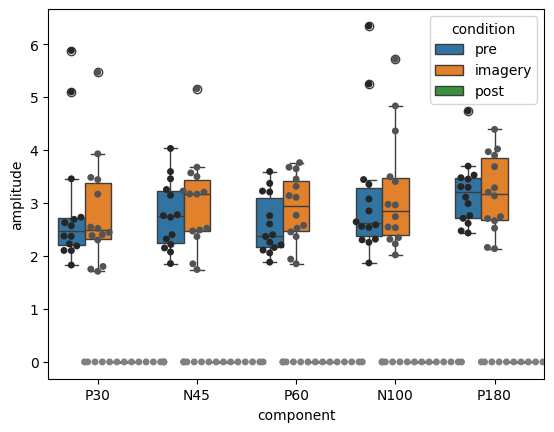

In [211]:
sns.boxplot(df.loc[df.hotspot == "SMA"], x="component", y="amplitude", hue="condition")
sns.swarmplot(df.loc[df.hotspot == "SMA"], x="component", y="amplitude", hue="condition", dodge=True, color="grey", legend=False)

In [192]:
parts = record.split("_")
coil = "T" if parts[-1].find("T") != -1 else 'qp'
angle = parts[-1][-6:-5] if parts[-1].find("p") != -1 else parts[-1][4:parts[-1].find("deg")]
df_concat.append({
    "hotspot": parts[0],
    "id": parts[2],
    "coil": coil, 
    "angle": angle, 
    "record": record

,subject,condition,component,amplitude,latency
0,M1_session_19__set_1_coilqppa.h5,pre,P30,14.257330,30.0
1,M1_session_19__set_1_coilqppa.h5,pre,N45,11.696127,47.5
2,M1_session_19__set_1_coilqppa.h5,pre,P60,12.399746,65.0
3,M1_session_19__set_1_coilqppa.h5,pre,N100,10.944704,110.0
4,M1_session_19__set_1_coilqppa.h5,pre,P180,8.101043,190.0
...,...,...,...,...,...
730,SMA_session_26__set_5_coil0deg.h5,post,P30,2.367253,30.0
731,SMA_session_26__set_5_coil0deg.h5,post,N45,3.152791,47.5
732,SMA_session_26__set_5_coil0deg.h5,post,P60,3.831672,65.0
733,SMA_session_26__set_5_coil0deg.h5,post,N100,2.303123,110.0


In [10]:
filename = r"../results/diff_phases_peaks_manual.json"
with open(filename, "r") as f:
    data = json.load(f)

In [36]:
DATASET = "pilot/M1_SMA_differentPhases/clean_epochs"
data_folder = os.path.join(r"../data", DATASET)
records = os.listdir(data_folder)
df_concat = []
for record in records:
    parts = record.split("_")
    coil = "T" if parts[-1].find("T") != -1 else 'qp'
    angle = parts[-1][-6:-5] if parts[-1].find("p") != -1 else parts[-1][4:parts[-1].find("deg")]
    df_concat.append({
        "hotspot": parts[0],
        "id": parts[2],
        "coil": coil, 
        "angle": angle, 
        "record": record
    })
df = pd.DataFrame(df_concat)
df.head()

,hotspot,id,coil,angle,record
0,M1,19,qp,Ф,M1_session_19__set_1_coilФpa.h5
1,M1,19,T,T,M1_session_19__set_2_coilTpa.h5
2,M1,19,T,T,M1_session_19__set_3_coilTap.h5
3,M1,20,T,T,M1_session_20__set_1_coilTap.h5
4,M1,20,T,T,M1_session_20__set_8_coilTpa.h5


In [112]:
import copy
conds = ["pre", "imagery", "post"]
df_teps = []
for record in data.keys():
    teps = data[record]

    parts = record.split("_")
    coil = "T" if parts[-1].find("T") != -1 else 'qp'
    angle = parts[-1][-5:-3] if parts[-1].find("p") != -1 else parts[-1][4:parts[-1].find("deg")]
    
    d_teps = {
        "record": record,
        "hotspot": parts[0],
        "id": parts[2],
        "coil": coil, 
        "angle": angle, 
    }

    # for name in ["hotspot", "id", "coil", "angle"]:
    #     d_teps[name] = df.loc[df.record == record][name].values[0]
    for i in [0, 1, 2]:
        for t, a in zip(teps[i]["t_peaks"], teps[i]["amp"]):
            d = copy.copy(d_teps)
            d["cond"] = conds[i]
            d["amp"] = a 
            d["tpeak"] = t

            df_teps.append(d)
df_teps = pd.DataFrame(df_teps)
df_teps

,record,hotspot,id,coil,angle,cond,amp,tpeak
0,M1_session_19__set_1_coilР¤pa.h5,M1,19,qp,pa,pre,20.718245,20.8
1,M1_session_19__set_1_coilР¤pa.h5,M1,19,qp,pa,pre,14.027013,60.6
2,M1_session_19__set_1_coilР¤pa.h5,M1,19,qp,pa,pre,12.165162,127.4
3,M1_session_19__set_1_coilР¤pa.h5,M1,19,qp,pa,imagery,22.255386,21.4
4,M1_session_19__set_1_coilР¤pa.h5,M1,19,qp,pa,imagery,13.611510,61.4
...,...,...,...,...,...,...,...,...
204,SMA_session_26__set_5_coil0deg.h5,SMA,26,qp,0,pre,3.597554,62.2
205,SMA_session_26__set_5_coil0deg.h5,SMA,26,qp,0,imagery,5.809116,18.0
206,SMA_session_26__set_5_coil0deg.h5,SMA,26,qp,0,imagery,4.483742,63.6
207,SMA_session_26__set_5_coil0deg.h5,SMA,26,qp,0,post,6.244559,17.8


In [121]:
windows = [(10, 35), (35, 60), (55, 75), (80, 140)]
title = ["P25", "N45", "P60", "N100"]

titles = []
for i, teps in enumerate(df_teps["tpeak"].values):
    peak = "no"
    for t, w in zip(title, windows):
        if teps > w[0] and teps < w[1]:
            peak = t
    titles.append(peak)
df_teps["peak"] = titles

<Axes: xlabel='peak', ylabel='amp'>

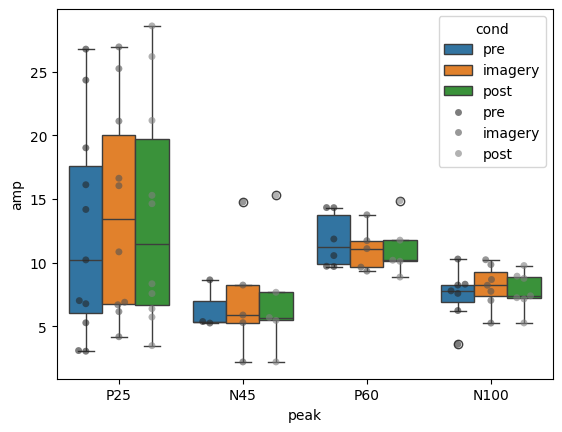

In [131]:
mask = (df_teps.peak != "no") & (df_teps.coil == "T") & (df_teps.hotspot == "M1")
# print(df_teps.loc[mask][["cond","peak"]].value_counts(sort=False))
sns.boxplot(df_teps.loc[mask], y="amp", x="peak", hue="cond", order=title)
sns.swarmplot(df_teps.loc[mask], y="amp", x="peak", hue="cond", dodge=True, palette='dark:grey', alpha=.6, order=title)

<Axes: xlabel='peak', ylabel='amp'>

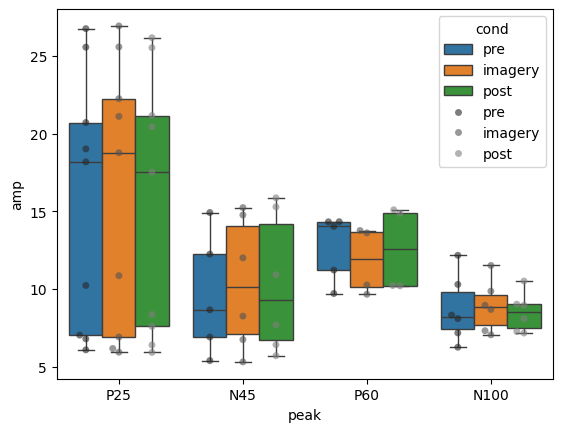

In [130]:
mask = (df_teps.peak != "no") & (df_teps.hotspot == "M1") & (df_teps.angle == "pa")
# print(df_teps.loc[mask][["cond","peak"]].value_counts(sort=False))
sns.boxplot(df_teps.loc[mask], y="amp", x="peak", hue="cond", order=title)
sns.swarmplot(df_teps.loc[mask], y="amp", x="peak", hue="cond", dodge=True, palette='dark:grey', alpha=.6, order=title)

<Axes: xlabel='peak', ylabel='amp'>

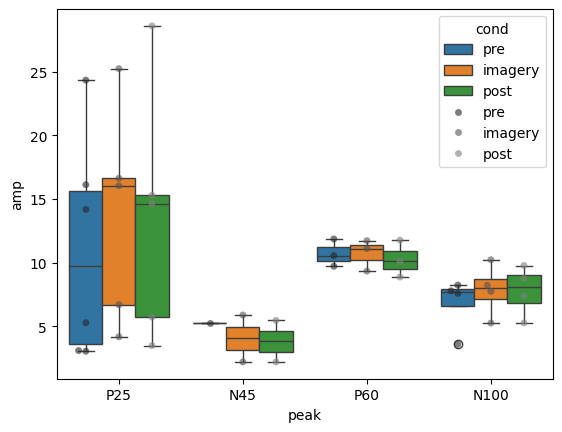

In [132]:
mask = (df_teps.peak != "no") & (df_teps.hotspot == "M1") & (df_teps.angle == "ap")
# print(df_teps.loc[mask][["cond","peak"]].value_counts(sort=False))
sns.boxplot(df_teps.loc[mask], y="amp", x="peak", hue="cond", order=title)
sns.swarmplot(df_teps.loc[mask], y="amp", x="peak", hue="cond", dodge=True, palette='dark:grey', alpha=.6, order=title)

<Axes: xlabel='peak', ylabel='amp'>

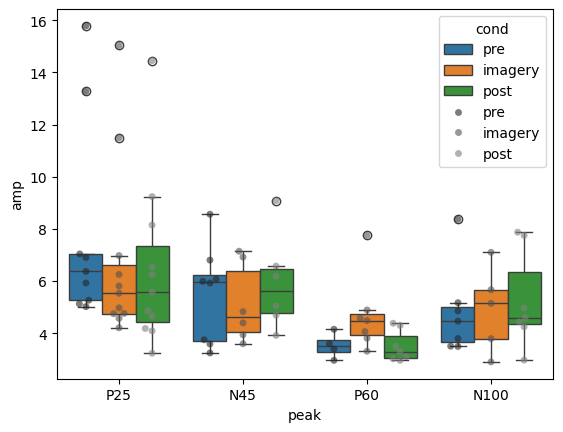

In [226]:
mask = (df_teps.peak != "no") & (df_teps.hotspot == "SMA")
var = "amp"
# print(df_teps.loc[mask][["cond","peak"]].value_counts(sort=False))
sns.boxplot(df_teps.loc[mask], y=var, x="peak", hue="cond", order=title)
sns.swarmplot(df_teps.loc[mask], y=var, x="peak", hue="cond", dodge=True, palette='dark:grey', alpha=.6, order=title)

In [147]:
import pingouin as pg

In [190]:
hotspot = "SMA"
conds = ["pre", "imagery", "post"]
for peak in ["P25", "N45", "P60", "N100"]:
    df_stat = df_teps.loc[(df_teps.peak == peak) & (df_teps.hotspot == hotspot)]
    df_tosave = pd.DataFrame()
    for cond in conds:
        d_cond = df_stat.loc[df_stat.cond == cond]
        # df_tosave[cond] = d_cond["amp"].values
        print(d_cond["amp"].values)
    break
# df_tosave

[ 6.36925697  5.01866293  5.26449537  6.90485382  7.04069471  5.12822533
 13.2727375  15.78639507  5.92358494]
[ 6.97638273  4.76030493  4.971663    5.53163528  6.25163126  4.20678949
  4.74693966 11.49192238  4.56778526 15.03778553  5.80911636]
[ 5.57296276  4.0867238   4.86525297  8.14798832  6.547122    4.64886618
  4.18093966  9.2396946   3.23007393 14.45430946  6.24455881]


In [ ]:

peak = "N100"
angle = "90"
df_p60 = df_teps.loc[(df_teps.peak == peak) & (df_teps.hotspot == hotspot) & (df_teps.angle == angle)]

In [229]:
hotspot = "M1"
angle = "pa"
var = "amp" 
for peak in ["P25", "N45", "P60", "N100"]:
    df_p60 = df_teps.loc[(df_teps.peak == peak) & (df_teps.hotspot == hotspot) & (df_teps.angle == angle)]
    print(peak)
    res = pg.friedman(
        data=df_p60,
        dv=var,
        within="cond",
        subject="record",
    )
    print(res["p_unc"].values)

P25
[0.23587708]
N45
[0.54881164]
P60
[0.17377394]
N100
[0.51341712]


In [212]:
hotspot = "SMA"
peak = "P25"
df_p60 = df_teps.loc[(df_teps.peak == peak) & (df_teps.hotspot == hotspot)]

In [224]:
hotspot = "SMA"
var = "amp" 
for peak in ["P25", "N45", "P60", "N100"]:
    df_p60 = df_teps.loc[(df_teps.peak == peak) & (df_teps.hotspot == hotspot)]
    print(peak)
    res = pg.friedman(
        data=df_p60,
        dv=var,
        within="cond",
        subject="record",
    )
    print(res["p_unc"].values)

P25
[0.04455143]
N45
[0.44932896]
P60
[0.16529889]
N100
[0.36787944]


In [225]:
df_p60 = df_teps.loc[(df_teps.peak == "P25") & (df_teps.hotspot == hotspot)]
# pairwise post-hoc для Friedman
posthoc = pg.pairwise_tests(
    data=df_p60,
    dv=var,
    within="cond",
    subject="record",
    parametric=False,   # непараметрический
    padjust="holm"      # корректировка на множественные сравнения
)

print(posthoc)

  Contrast        A     B  Paired  Parametric  W_val alternative     p_unc  \
0     cond  imagery  post    True       False   16.0   two-sided  0.496094   
1     cond  imagery   pre    True       False    4.0   two-sided  0.027344   
2     cond     post   pre    True       False    8.0   two-sided  0.097656   

     p_corr p_adjust    hedges  
0  0.496094     holm  0.053491  
1  0.082031     holm -0.152164  
2  0.195312     holm -0.210250  
